In [1]:
import librosa
import soundfile as sf
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import torch
import os
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()
hf_token = os.environ["HF_TOKEN"]
login(token=hf_token)

pre_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [2]:

# audio to numpy
#audio, sr = librosa.load("Stimuli\Raw_resampled\dash-tash_F0_11_VOT_11.wav", sr=16000)
#sf.write("dash-tash_11_resampled.wav", audio, 16000)

# load a soundfile in 16kHz
dash, sr = librosa.load("Stimuli\Continua\dash-tash\dash-tash_F0_01_VOT_01.wav", sr=16000)

In [9]:
print(dash.shape)

(19541,)


In [11]:
# preprocess numpy audio to tensors
pre_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
dash_tensor = pre_processor(dash, sampling_rate=sr, return_tensors='pt')

print(dash_tensor)
print(dash_tensor['input_values'].shape)

{'input_values': tensor([[-0.0016, -0.0016, -0.0016,  ...,  0.0036,  0.0048,  0.0065]])}
torch.Size([1, 19541])


In [49]:
# run CNN and 12-layer transformer
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

with torch.no_grad():
    embeddings = model(**dash_tensor, output_hidden_states=True, padding=False)


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [50]:
# output of the first hidden layer (CNN)
print(embeddings.hidden_states[0][0][3].shape)

print(embeddings.hidden_states[0].shape)

torch.Size([768])
torch.Size([1, 60, 768])


In [59]:
start_frame = int(0.05 / 0.02)
# +1 accounts for exclusive stop index 
end_frame = int(0.43 / 0.02) + 1

In [58]:
print(start_frame, end_frame)

2 22


In [66]:
x = embeddings.hidden_states[0][0, start_frame:end_frame, :]

print(x.shape)
print(x.mean().shape)
print(x.mean(dim=0).shape)
print(x.mean(dim=1).shape)

torch.Size([20, 768])
torch.Size([])
torch.Size([768])
torch.Size([20])


In [68]:
start_frame = int(0.05 // 0.02)

# +1 accounts for exclusive stop index later on
end_frame = int(0.43 // 0.02) + 1

# take hidden representations for a specific layer and time window, then average them into a single vector
mean = embeddings.hidden_states[0][0, start_frame:end_frame, :].mean(dim=0)
print(mean.shape)

# should be 13 (CNN + 12 transformer layers)
print(len(embeddings.hidden_states))

# CNN output shape
print(embeddings.hidden_states[0].shape)

torch.Size([768])
13
torch.Size([1, 60, 768])


In [77]:
dash_embed = {}

steps = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11"]

dash_embed["0"] = {}
dash_embed["0"]["01"] = mean.numpy()

print(dash_embed)



{'0': {'01': array([ 8.64182264e-02, -2.54487723e-01, -7.24762157e-02,  1.53421089e-01,
        1.02488898e-01, -1.49845794e-01,  2.48938367e-01,  2.46201884e-02,
        1.48067102e-01,  4.66208979e-02, -4.67908420e-02, -1.49969131e-01,
        7.11348047e-03, -6.33829460e-03, -8.70637745e-02, -2.47098163e-01,
       -7.43969679e-02, -1.13828160e-01,  7.26076961e-03, -1.31483702e-02,
       -1.58741310e-01, -2.36892134e-01,  4.70540047e-01, -5.41251190e-02,
       -1.90321654e-02,  4.46459465e-02,  4.09195572e-01,  1.06143937e-01,
       -7.43202046e-02,  6.92584366e-02, -1.03223458e-01,  6.74732774e-02,
       -2.20817365e-02, -1.18561089e-02,  1.85280386e-02,  2.71487892e-01,
        6.94224238e-02,  2.88183428e-02, -2.48541590e-02,  1.78378783e-02,
        7.82216638e-02, -2.08362080e-02, -7.44860545e-02, -4.85592559e-02,
       -1.47197634e-01,  3.88529114e-02, -6.20806925e-02,  8.39036927e-02,
        3.86503376e-02,  1.81265041e-01,  6.46609515e-02,  1.63241655e-01,
       -7.72

In [69]:
from pathlib import Path

def get_continuum_embeddings(sound_name):
    model.eval()
    start_frame = int(0.05 / 0.02)
    steps = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11"]
    embed_dict = {}

    for layer in range(13):
        embed_dict[layer] = {}
    
    for i, step in enumerate(steps):
        # load and preprocess
        sound, sr = librosa.load(f"Stimuli/Continua/{sound_name}/{sound_name}_F0_{step}_VOT_{step}.wav", sr=16000)
        sound_tensor = pre_processor(sound, sampling_rate=sr, return_tensors='pt')

        # max: prevent an error for the first frame where VOT = 0
        end_frame = max(int((0.05 + i * 0.009) // 0.02), start_frame + 1)
    
        # run wav2vec2, wav2vec2 builds representations of the ENTIRE word
        with torch.no_grad():
            embeddings = model(**sound_tensor, output_hidden_states=True)
    
        # extract /d/-/t/ embeddings of each layer
        for layer in range(13):
            mean = embeddings.hidden_states[layer][0, start_frame:end_frame, :].mean(dim=0)
            embed_dict[layer][step] = mean.numpy()

    return embed_dict

dash_tash_embed = get_continuum_embeddings("dash-tash")
task_dask_embed = get_continuum_embeddings("task-dask")


In [78]:
print(dash_tash_embed[0]["01"].shape)
#print(dash_tash_embed)

(768,)


In [74]:
def lala(x, t, d):
    """Projection of x onto dt axis, scaled so d=-1 and t=+1."""
    v = t - d
    v_norm = np.dot(v, v)
    # normalize so that midpoint = 0, full t alignment = 1, d-alignment = -1
    m = (t + d) / 2
    v_normalized = (v / v_norm)

   # v / v_norm normalizes the axis vector
    projection = np.dot(x - m, v_normalized)
    return score


def projection_score(x, t, d):
    """Projection onto d→t axis, scaled so d=-1 and t=+1."""
    v = t - d
    v_norm_sq = np.dot(v, v)

    m = (t + d) / 2

    score = 2 * np.dot(x - m, v) / v_norm_sq
    return score

def get_endpoints():
    endpoints = {}

    for layer in range(13):
        t = np.mean([
            dash_tash_embed[layer]["11"],
            task_dask_embed[layer]["11"]
        ], axis=0)

        d = np.mean([
            dash_tash_embed[layer]["01"],
            task_dask_embed[layer]["01"]
        ], axis=0)

        endpoints[layer] = {"t": t, "d": d}

    return endpoints


def get_embed_sim(embed_dict_input, endpoints):
    projections = {}
    steps = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11"]
    
    for layer in range(13):
        projections[layer] = []
        
        t = endpoints[layer]["t"]
        d = endpoints[layer]["d"]
        
        for step in steps:
            x = embed_dict_input[layer][step]
            score = projection_score(x, t, d)
            projections[layer].append(score)
            
    return projections

    
endpoints = get_endpoints()
results_dash = get_embed_sim(dash_tash_embed, endpoints)
results_task = get_embed_sim(task_dask_embed, endpoints)

In [79]:
print(results_dash)

{0: [np.float32(-1.0322763), np.float32(-0.8735119), np.float32(-0.31307197), np.float32(-0.16532098), np.float32(0.34146458), np.float32(0.43384174), np.float32(0.6995237), np.float32(0.83990175), np.float32(0.88095814), np.float32(1.0376859), np.float32(1.0192318)], 1: [np.float32(-0.9546849), np.float32(-0.986985), np.float32(-0.37348208), np.float32(-0.16542564), np.float32(0.2513521), np.float32(0.3627983), np.float32(0.65283555), np.float32(0.7709086), np.float32(0.81461763), np.float32(0.99074), np.float32(0.98841256)], 2: [np.float32(-1.0456558), np.float32(-0.8380551), np.float32(-0.29875717), np.float32(-0.1382575), np.float32(0.2121288), np.float32(0.34139395), np.float32(0.60572934), np.float32(0.7428417), np.float32(0.8122759), np.float32(1.0231003), np.float32(1.0153283)], 3: [np.float32(-1.0070251), np.float32(-0.7258552), np.float32(-0.28306368), np.float32(-0.071237), np.float32(0.26691383), np.float32(0.42679718), np.float32(0.67924166), np.float32(0.7666713), np.floa

In [80]:

def cosine_distance(x, endpoint):
    dot_product = np.dot(x, endpoint)
    norm_x = np.linalg.norm(x)
    norm_endpoint = np.linalg.norm(endpoint)
    
    return 1 - (dot_product / (norm_x * norm_endpoint))

def cosine_sim(x, t, d):
    cos_dist_x_t = cosine_distance(x, t)
    cos_dist_x_d = cosine_distance(x, d)
    sim_x_t = 1 - (cos_dist_x_t / (cos_dist_x_t + cos_dist_x_d))
    
    return sim_x_t

def get_embed_sim(embed_dict_input):
    similarities = {}
    steps = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11"]
    endpoints = get_endpoints()
    
    for layer in range(13):
        t = endpoints[layer]["t"]
        d = endpoints[layer]["d"]
        similarities[layer] = []
        
        for step in steps:
            embed_sim = cosine_sim(embed_dict_input[layer][step], t, d)
            similarities[layer].append(embed_sim)
            
    return similarities

results_dash = get_embed_sim(dash_tash_embed)
results_task = get_embed_sim(task_dask_embed)

In [81]:
print(results_dash[0])

[np.float32(0.060094595), np.float32(0.14996737), np.float32(0.36987865), np.float32(0.40894353), np.float32(0.554942), np.float32(0.5888777), np.float32(0.73847675), np.float32(0.78610593), np.float32(0.8960273), np.float32(0.9082902), np.float32(0.95778286)]


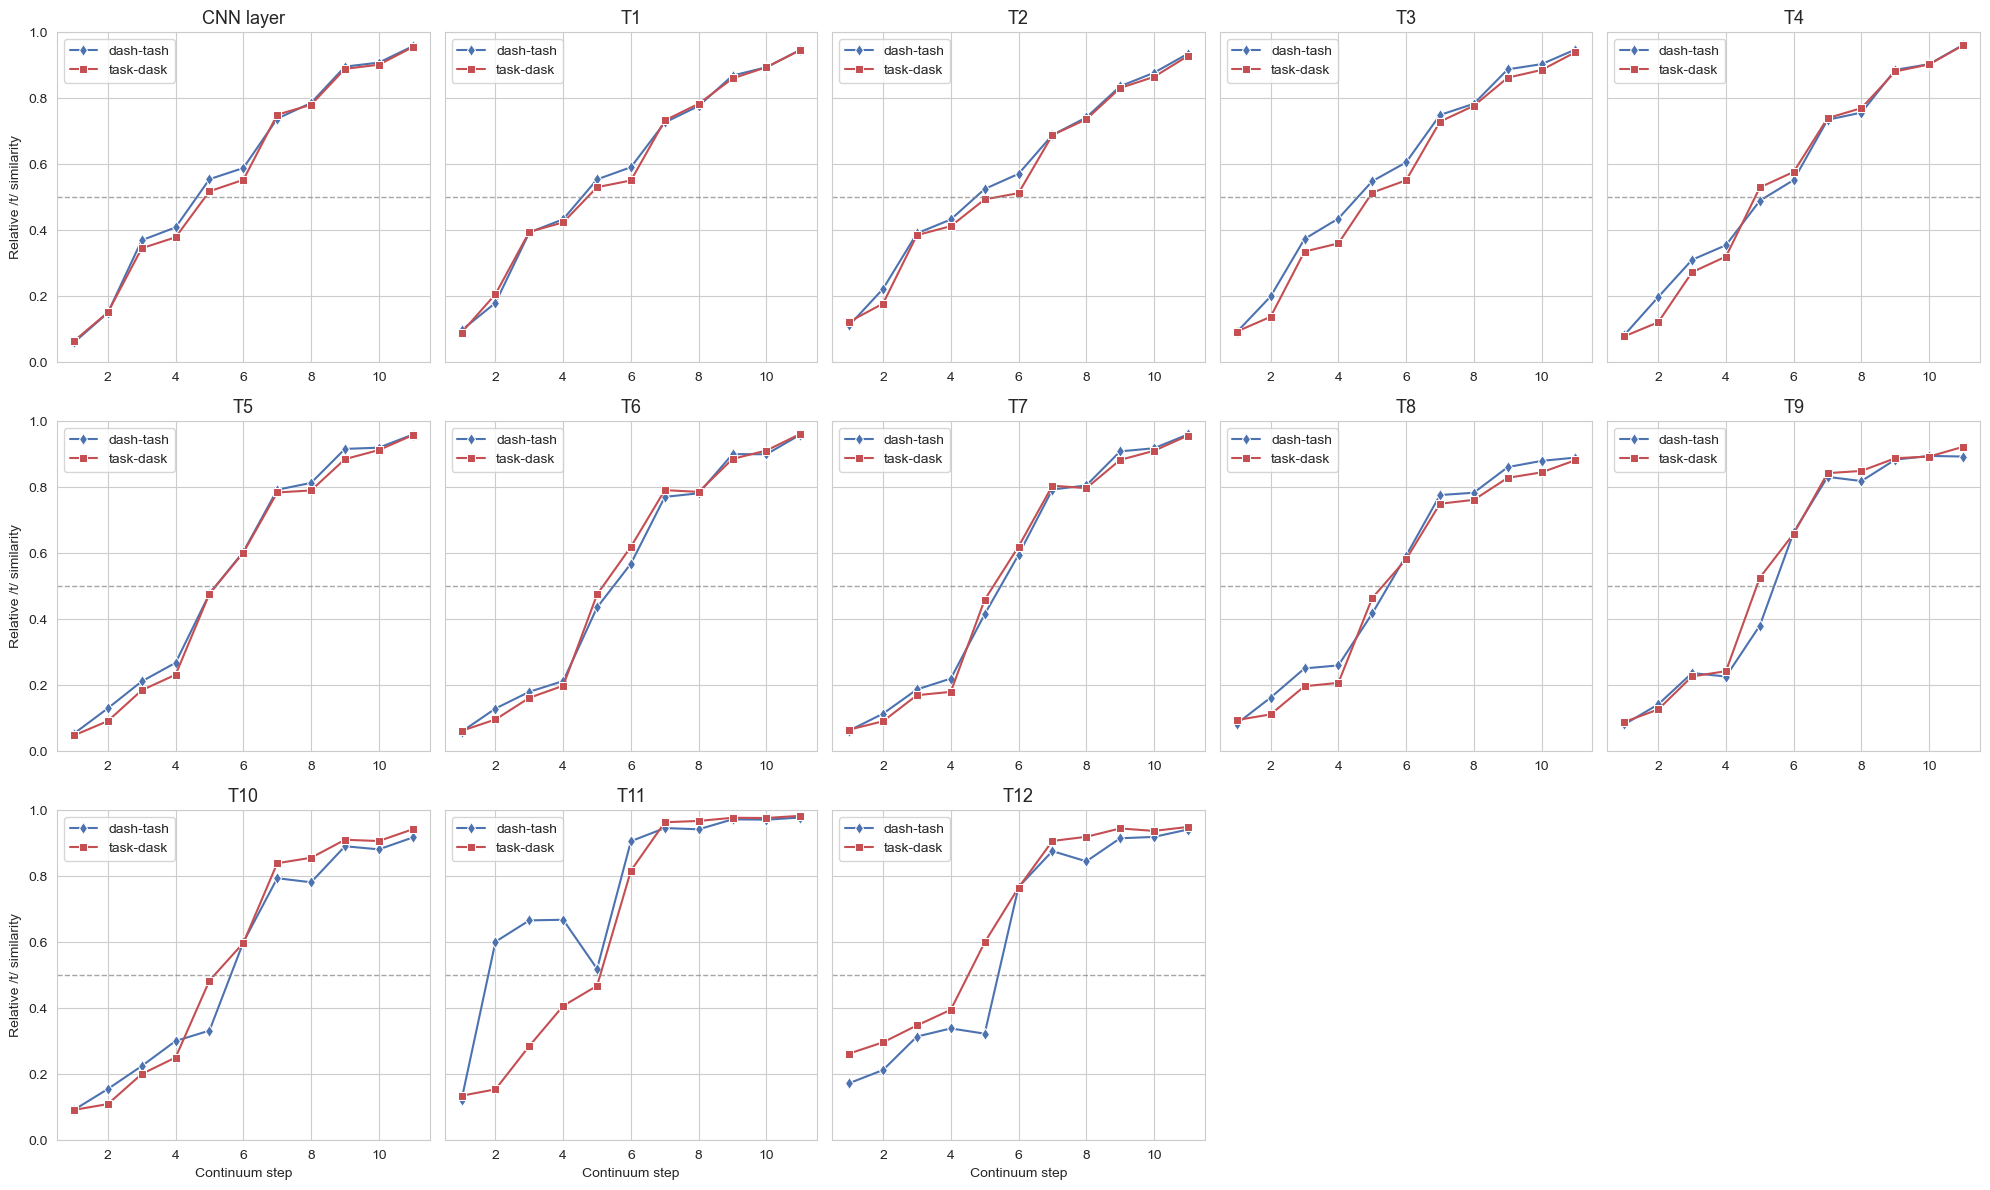

In [130]:

sns.set_style("whitegrid")
fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()
plt.ylim(0, 1)

for layer in range(13):
    ax = axes[layer]
    
    sns.lineplot(x=range(1, 12), y=results_dash[layer], ax=ax, label="dash-tash", color="#4C72B0", marker='d')
    sns.lineplot(x=range(1, 12), y=results_task[layer], ax=ax, label="task-dask", color="#C44E52", marker='s')

    # 0.5 crossover reference line
    ax.axhline(
        y=0.5,
        linestyle="--",
        color="gray",
        alpha=0.7,
        linewidth=1
    )
    
    ax.tick_params(labelbottom=True)
    ax.set_xlabel("")
    
    if layer == 0:
        ax.set_title(f"CNN layer", fontsize=13)
    else:
        ax.set_title(f"T{layer}", fontsize=13)

    if layer in [0, 5, 10]:

        ax.set_ylabel("Relative /t/ similarity")
    else:
        ax.tick_params(labelleft=False)

    for ax in axes[13:]:
        ax.axis("off")


plt.tight_layout()
plt.savefig("base_pretrained.png", dpi=300)
plt.show()

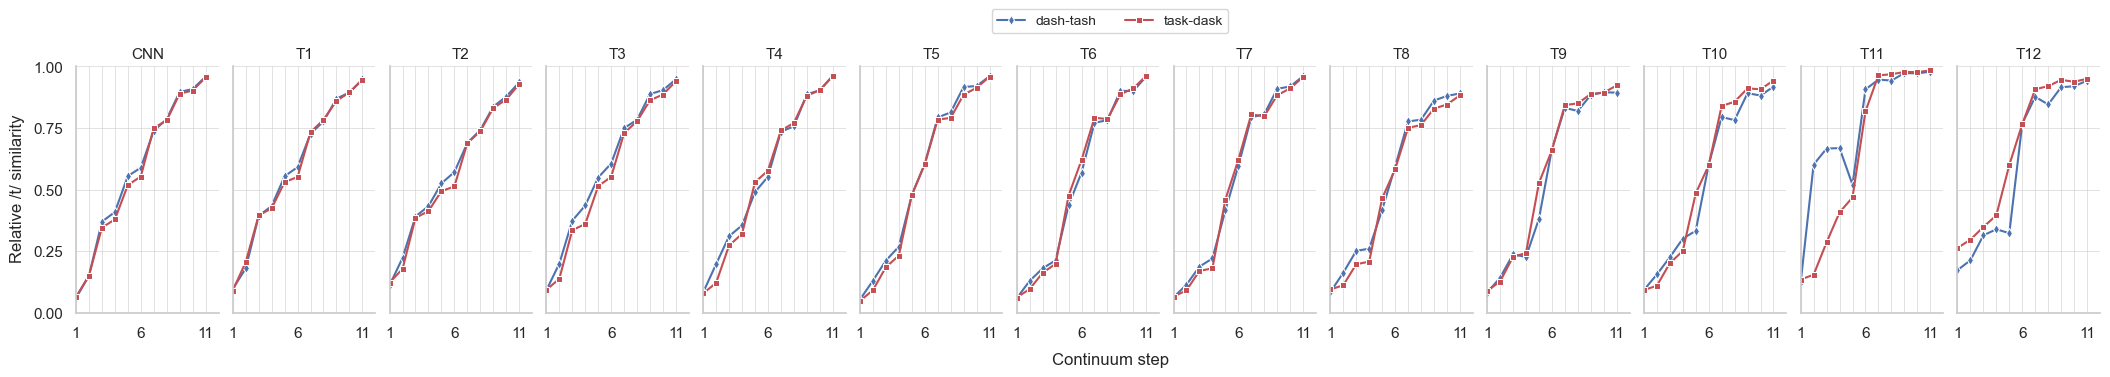

In [191]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

x = np.arange(1, 12)
layer_names = ["CNN"] + [f"T{i}" for i in range(1, 13)]

fig, axes = plt.subplots(
    1, 13,
    figsize=(22, 3.2),
    sharex=True,
    sharey=True
)

for layer, ax in enumerate(axes):
    sns.lineplot(
        x=x,
        y=results_dash[layer],
        ax=ax,
        color="#4C72B0",
        marker="d",
        markersize=5,
        label="dash-tash"
    )

    sns.lineplot(
        x=x,
        y=results_task[layer],
        ax=ax,
        color="#C44E52",
        marker="s",
        markersize=5,
        label="task-dask"
    )

    ax.set_title(layer_names[layer], fontsize=11)

    ax.set_xlim(1, 12)
    ax.set_ylim(0, 1)

    ax.set_xticks(range(1, 12))
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(["1", "", "", "", "", "6", "", "", "", "", "11"])
    
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.grid(True, linewidth=0.4)

    # only keep y tick labels on first panel
    if layer != 0:
        ax.tick_params(labelleft=False)

    # remove repeated legends
    ax.legend().remove()

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=True,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.08)
)

# shared axis labels
fig.text(
    0.5,
    -0.05,
    "Continuum step",
    ha="center",
    fontsize=12
)

fig.text(
    0,
    0.5,
    "Relative /t/ similarity",
    va="center",
    rotation="vertical",
    fontsize=12
)

sns.despine()

plt.subplots_adjust(
    left=0.03,
    right=0.95,
    wspace=0.1
)

plt.savefig("base_pretrained_improved_style.png", dpi=300, bbox_inches="tight")
plt.show()

In [93]:
# some checks
print(dash_tash_embed[4]["11"].shape)
print(dash_tash_embed.keys())
print(dash_tash_embed[0].keys())

print(task_dask_embed[3]["03"].shape)
print(task_dask_embed.keys())
print(task_dask_embed[0].keys())

(768,)
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
dict_keys(['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11'])
(768,)
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
dict_keys(['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11'])


In [ ]:
for step in steps:
    continuum_step, sr = librosa.load(f"Stimuli/Continua/dash-tash/dash-tash_F0_{step}_VOT_{step}.wav", sr=16000)
    
    tensor = pre_processor(continuum_step, sampling_rate=sr, return_tensors='pt')
    logits = model(**tensor).logits
    predicted_ids = torch.argmax(logits, dim=-1)
    transcription = pre_processor.batch_decode(predicted_ids)
    transcripts.append(transcription)